In [1]:
# Importation des bibliothèques requises
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import vectorbt as vbt
from bokeh.io import output_notebook
from binance.client import Client
from utils import (
    fetch_multiple_cryptos, process_multiple_cryptos, 
    plot_crypto, quick_analysis
)
# Configuration pour les visualisations
plt.style.use('dark_background')
output_notebook()

Loading BokehJS ...

---
### Téléchargement des données
> local si fichier existant / téléchargement depuis API et sauvegarde sinon

In [2]:
# Configuration des paramètres et chargement des données
# Attention au biais du survivant/sélection dans le choix des actifs
# Ne jamais backtester/rechercher sur un seul actif ... 
crypto_list = ['ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'DOGEUSDT', 
               'ADAUSDT', 'DOTUSDT', 'LINKUSDT', 'LTCUSDT', 'AAVEUSDT']

# Date de début et de fin
start_date = "2022-01-01"
end_date = "2025-08-01"

# Charger ou télécharger les données
if os.path.exists("crypto_data.parquet"):
    print("Chargement des données depuis le fichier local...")
    crypto_df = pd.read_parquet("crypto_data.parquet")
else:
    print("Téléchargement depuis Binance...")
    crypto_df = fetch_multiple_cryptos(crypto_list, start_date, end_date, Client.KLINE_INTERVAL_4HOUR)
    crypto_df.to_parquet("crypto_data.parquet")

Chargement des données depuis le fichier local...


In [3]:
crypto_df.head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,symbol
close_time,,,,,,,,,,
2022-01-01 03:59:59.999,253.9000,264.400,253.800,261.2000,15816.45,4.118672e+06,19130,8987.97500000,2340998.95400000,AAVEUSDT
2022-01-01 03:59:59.999,1.3080,1.338,1.307,1.3250,10338558.60,1.371088e+07,21814,5842627.50000000,7748145.40860000,ADAUSDT
2022-01-01 03:59:59.999,511.5000,520.000,511.400,518.1000,62579.19,3.235729e+07,46138,30979.18800000,16014822.39120000,BNBUSDT
2022-01-01 03:59:59.999,0.1703,0.173,0.170,0.1714,50156952.00,8.612467e+06,12258,29484400.00000000,5064911.00560000,DOGEUSDT
2022-01-01 03:59:59.999,26.6700,27.440,26.660,27.1800,664582.93,1.805870e+07,30653,322394.86000000,8756972.57700000,DOTUSDT


---
### Création des indicateurs et signaux

In [4]:
# Génération des features/indicateurs et des signaux
cryptos_with_indicators = process_multiple_cryptos(
    crypto_df=crypto_df,         # DataFrame contenant les prixs des actifs
    crypto_list=crypto_list,     # Liste des actifs à analyser
    max_holding_periods=50,      # None pour aucune limite ou alors X bars (ex. 30 bars)
    short_window=20,             # Fenêtre courte pour le calcul de la Tstatistique Courte
    long_window=200,             # Fenêtre longue pour le calcul de la Tstatistique Longue
    sma_window=30,               # Fenêtre pour la SMA de la Tstatistique longue
    short_up_level=1.0,          # Niveau supérieur pour le signal d'achat
    short_down_level=-3.0,       # Niveau inférieur pour le signal de vente
    long_min_threshold=0         # Seuil minimum de la Tstatistique Longue pour le signal d'achat (evite les periodes fortement baissière)
)

Traitement de ETHUSDT...
Traitement de BNBUSDT...
Traitement de SOLUSDT...
Traitement de XRPUSDT...
Traitement de DOGEUSDT...
Traitement de ADAUSDT...
Traitement de DOTUSDT...
Traitement de LINKUSDT...
Traitement de LTCUSDT...
Traitement de AAVEUSDT...


In [5]:
#cryptos_with_indicators
cryptos_with_indicators['ETHUSDT'].head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,symbol,trend_tstat_short,trend_tstat_long,trend_tstat_long_sma,signal
close_time,,,,,,,,,,,,,,
2022-02-08 03:59:59.999,3139.77,3157.40,3112.00,3146.45,57427.3072,1.803463e+08,107496,27614.27970000,86719135.23404900,ETHUSDT,6.327251,-9.945177,-17.749661,0
2022-02-08 07:59:59.999,3146.46,3232.87,3142.35,3174.11,110663.5902,3.522716e+08,193713,59084.94880000,188120816.19676900,ETHUSDT,6.990857,-9.476008,-17.234583,0
2022-02-08 11:59:59.999,3174.11,3178.66,3073.57,3105.20,113464.8090,3.526001e+08,211430,55081.37430000,171152115.31165800,ETHUSDT,6.642269,-9.096919,-16.715016,0
2022-02-08 15:59:59.999,3105.19,3105.20,3029.20,3076.19,97760.2090,3.002317e+08,167340,46653.65190000,143296980.71139100,ETHUSDT,5.500344,-8.744668,-16.192587,0
2022-02-08 19:59:59.999,3076.18,3084.98,3025.21,3051.60,69953.6050,2.136146e+08,117572,34428.68530000,105159910.04482800,ETHUSDT,4.191822,-8.448695,-15.667266,0


---
### Inspection Visuelle des signaux

In [6]:
# Visualisation individuelle
plot_crypto(cryptos_with_indicators, 'DOTUSDT', start_date='2024-01-01')

---
### Backtest

In [7]:
# Préparation des données pour le backtest avec VectorBT
# 1. Récupération et tri des symboles disponibles
symbols = sorted(cryptos_with_indicators.keys())

# 2. Construction de la matrice des prix de clôture pour chaque crypto
# Chaque colonne correspond à un actif, chaque ligne à une date
prices = pd.concat(
    [cryptos_with_indicators[sym]['close'].rename(sym) for sym in symbols],
    axis=1
).sort_index()

# 3. Construction de la matrice des signaux (1 = achat, -1 = vente, 0 = rien)
# On s'assure que les signaux sont bien alignés sur les dates de 'prices'
signals = pd.concat(
    [cryptos_with_indicators[sym]['signal'].fillna(0).astype(int).rename(sym) for sym in symbols],
    axis=1
).reindex(prices.index, fill_value=0)

# 4. Détection des événements d'entrée (passage à 1) et de sortie (passage à -1)
entries = (signals == 1) & (signals.shift(1) != 1)
exits = (signals == -1) & (signals.shift(1) != -1)

In [8]:
# Backtest avec VectorBT
pf = vbt.Portfolio.from_signals(
    close=prices, entries=entries, exits=exits,
    size=0.3, size_type='Percent', init_cash=100_000,
    cash_sharing=True, fees=0.001, slippage=0.001, freq='4H'
)

# Affichage des résultats
print(pf.stats())

Start                         2022-02-08 03:59:59.999000
End                           2025-08-01 03:59:59.999000
Period                                1270 days 04:00:00
Start Value                                     100000.0
End Value                                   255185.42248
Total Return [%]                              155.185422
Benchmark Return [%]                           29.368473
Max Gross Exposure [%]                         97.279962
Total Fees Paid                             15572.319411
Max Drawdown [%]                               24.599835
Max Drawdown Duration                  370 days 04:00:00
Total Trades                                         349
Total Closed Trades                                  349
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   38.968481
Best Trade [%]                                123.105425
Worst Trade [%]                

In [9]:
# Graphique du portefeuille
pf.plot().show()

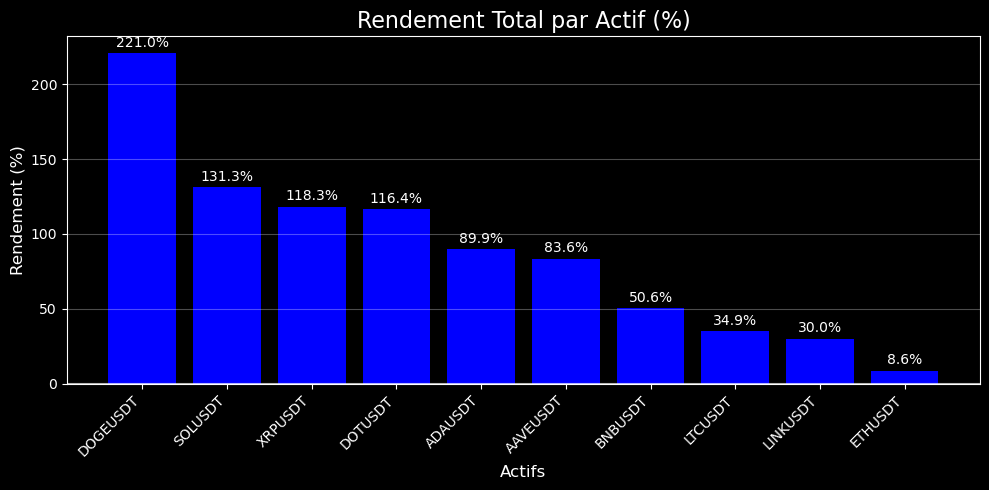

In [10]:
# Analyse détaillée des performances par actif
trades = pf.trades.records_readable
returns_by_asset = trades.groupby('Column')['Return'].sum().sort_values(ascending=False) * 100

# Graphique des rendements
plt.figure(figsize=(10, 5))
bars = plt.bar(returns_by_asset.index, returns_by_asset.values, 
               color=['blue' if x > 0 else 'red' for x in returns_by_asset.values])

plt.title('Rendement Total par Actif (%)', fontsize=16, color='white')
plt.xlabel('Actifs', fontsize=12, color='white')
plt.ylabel('Rendement (%)', fontsize=12, color='white')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='white', linestyle='-', alpha=0.7)

# Labels des valeurs
for i, v in enumerate(returns_by_asset.values):
    plt.text(i, v + (max(returns_by_asset.values) * 0.01), f'{v:.1f}%', 
             ha='center', va='bottom', color='white')

plt.tight_layout()
plt.show()